In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [3]:
df = pd.read_parquet(r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\15_min\df_BU_TotActPwr_Academy.parquet")

assert isinstance(df.index, pd.DatetimeIndex), "Index must be DatetimeIndex"
assert df.index.is_monotonic_increasing, "Index must be sorted"
assert not df.index.has_duplicates, "Datetime index has duplicates"

print("Loaded dataframe shape:", df.shape)


Loaded dataframe shape: (10656, 39)


### Train validation test

In [3]:

# =========================================================
# 2. DEFINE TARGET
# =========================================================
target_col = "BU_TotActPwr_Academy"   # change if needed

# all columns except target
feature_cols = [c for c in df.columns if c != target_col]

print("Target:", target_col)
print("No. of features:", len(feature_cols))

# =========================================================
# 3. HORIZONS
# =========================================================
HORIZONS = {
    "1h": 4,
    "1d": 96
}

# =========================================================
# 4. METRICS
# =========================================================
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2
    }

# =========================================================
# 5. MAIN FUNCTION: TRAIN / VAL / TEST
# =========================================================
def train_xgb_with_train_val_test(
    df,
    target_col,
    feature_cols,
    horizon_steps,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=42
):
    # -----------------------------
    # Safety check
    # -----------------------------
    total_ratio = train_ratio + val_ratio + test_ratio
    if not np.isclose(total_ratio, 1.0):
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.0")

    data = df.copy()

    # Create future target
    data["target_future"] = data[target_col].shift(-horizon_steps)

    # Drop rows where future target is missing
    data = data.dropna(subset=["target_future"])

    # If you want identical rows across models, uncomment this:
    data = data.dropna(subset=feature_cols)

    X = data[feature_cols]
    y = data["target_future"]

    # -----------------------------
    # Chronological split
    # -----------------------------
    n_total = len(data)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)
    n_test  = n_total - n_train - n_val

    X_train = X.iloc[:n_train]
    y_train = y.iloc[:n_train]

    X_val = X.iloc[n_train:n_train + n_val]
    y_val = y.iloc[n_train:n_train + n_val]

    X_test = X.iloc[n_train + n_val:]
    y_test = y.iloc[n_train + n_val:]

    print("\n" + "=" * 70)
    print(f"Horizon steps: {horizon_steps}")
    print(f"Total samples : {n_total}")
    print(f"Train samples : {len(X_train)}")
    print(f"Val samples   : {len(X_val)}")
    print(f"Test samples  : {len(X_test)}")

    print(f"Train period  : {X_train.index.min()} --> {X_train.index.max()}")
    print(f"Val period    : {X_val.index.min()} --> {X_val.index.max()}")
    print(f"Test period   : {X_test.index.min()} --> {X_test.index.max()}")

    # -----------------------------
    # Model
    # -----------------------------
    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=random_state,
        n_jobs=-1
    )

    # -----------------------------
    # Fit with validation set
    # -----------------------------
    # Basic fit:
    model.fit(X_train, y_train)

    # If your XGBoost version supports early stopping, use this instead:
    # model.fit(
    #     X_train,
    #     y_train,
    #     eval_set=[(X_val, y_val)],
    #     verbose=False
    # )

    # If early_stopping_rounds works in your version, use:
    # model.fit(
    #     X_train,
    #     y_train,
    #     eval_set=[(X_val, y_val)],
    #     early_stopping_rounds=50,
    #     verbose=False
    # )

    # -----------------------------
    # Validation predictions
    # -----------------------------
    y_val_pred = model.predict(X_val)
    val_metrics = calc_metrics(y_val.values, y_val_pred)

    print("\nValidation Metrics:")
    print(val_metrics)

    # -----------------------------
    # Test predictions
    # -----------------------------
    y_test_pred = model.predict(X_test)
    test_metrics = calc_metrics(y_test.values, y_test_pred)

    print("\nTest Metrics:")
    print(test_metrics)

    # -----------------------------
    # Save outputs
    # -----------------------------
    val_predictions = pd.DataFrame({
        "y_true": y_val,
        "y_pred": y_val_pred
    }, index=y_val.index)

    test_predictions = pd.DataFrame({
        "y_true": y_test,
        "y_pred": y_test_pred
    }, index=y_test.index)

    feature_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    return {
        "model": model,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "val_predictions": val_predictions,
        "test_predictions": test_predictions,
        "feature_importance": feature_importance,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test
    }



Target: BU_TotActPwr_Academy
No. of features: 38


In [4]:
# =========================================================
# 6. RUN FOR 1-HOUR
# =========================================================
results_xgb_1h = train_xgb_with_train_val_test(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1h"],
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
)





Horizon steps: 4
Total samples : 10652
Train samples : 7456
Val samples   : 1597
Test samples  : 1599
Train period  : 2025-10-21 00:00:00 --> 2026-01-06 15:45:00
Val period    : 2026-01-06 16:00:00 --> 2026-01-23 07:00:00
Test period   : 2026-01-23 07:15:00 --> 2026-02-08 22:45:00

Validation Metrics:
{'MAE': 1.2556233632153038, 'RMSE': np.float64(2.2232785069356606), 'MAPE_%': np.float64(16.544636636179355), 'R2': 0.8507678140128191}

Test Metrics:
{'MAE': 1.681269200867396, 'RMSE': np.float64(2.793267582835892), 'MAPE_%': np.float64(17.069925597107225), 'R2': 0.8565691775081191}


In [5]:
# =========================================================
# 7. RUN FOR 1-DAY
# =========================================================
results_xgb_1d = train_xgb_with_train_val_test(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1d"],
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
)



Horizon steps: 96
Total samples : 10560
Train samples : 7391
Val samples   : 1584
Test samples  : 1585
Train period  : 2025-10-21 00:00:00 --> 2026-01-05 23:30:00
Val period    : 2026-01-05 23:45:00 --> 2026-01-22 11:30:00
Test period   : 2026-01-22 11:45:00 --> 2026-02-07 23:45:00

Validation Metrics:
{'MAE': 2.0256957751828977, 'RMSE': np.float64(3.22487735441088), 'MAPE_%': np.float64(28.120956058549023), 'R2': 0.6901763929776752}

Test Metrics:
{'MAE': 2.393773932470039, 'RMSE': np.float64(3.9506034449415455), 'MAPE_%': np.float64(22.58398071766301), 'R2': 0.7138914238520805}


In [6]:
# =========================================================
# 8. SEE RESULTS
# =========================================================
print("\n1H Validation Metrics")
print(results_xgb_1h["val_metrics"])

print("\n1H Test Metrics")
print(results_xgb_1h["test_metrics"])

print("\n1D Validation Metrics")
print(results_xgb_1d["val_metrics"])

print("\n1D Test Metrics")
print(results_xgb_1d["test_metrics"])

print("\nTop 15 Features - 1H")
print(results_xgb_1h["feature_importance"].head(15))

print("\nTop 15 Features - 1D")
print(results_xgb_1d["feature_importance"].head(15))


1H Validation Metrics
{'MAE': 1.2556233632153038, 'RMSE': np.float64(2.2232785069356606), 'MAPE_%': np.float64(16.544636636179355), 'R2': 0.8507678140128191}

1H Test Metrics
{'MAE': 1.681269200867396, 'RMSE': np.float64(2.793267582835892), 'MAPE_%': np.float64(17.069925597107225), 'R2': 0.8565691775081191}

1D Validation Metrics
{'MAE': 2.0256957751828977, 'RMSE': np.float64(3.22487735441088), 'MAPE_%': np.float64(28.120956058549023), 'R2': 0.6901763929776752}

1D Test Metrics
{'MAE': 2.393773932470039, 'RMSE': np.float64(3.9506034449415455), 'MAPE_%': np.float64(22.58398071766301), 'R2': 0.7138914238520805}

Top 15 Features - 1H
                             feature  importance
17                         slot_5min    0.277539
18        BU_TotActPwr_Academy_lag_1    0.276815
6                               hour    0.092843
9                      minute_of_day    0.081737
5                         is_weekend    0.042597
19        BU_TotActPwr_Academy_lag_2    0.039541
11               

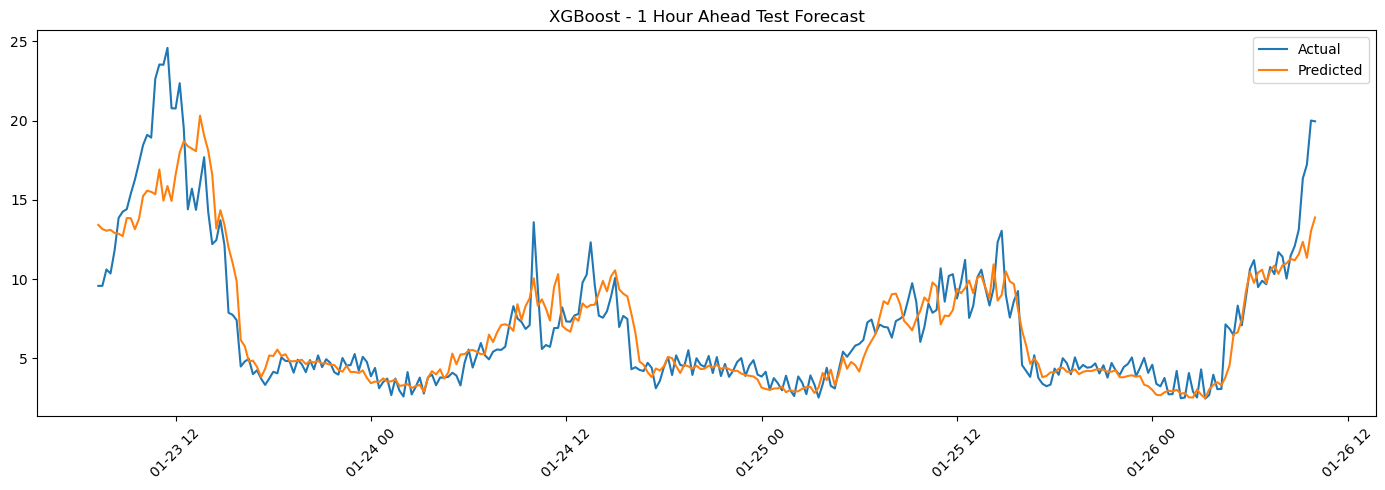

In [7]:
import matplotlib.pyplot as plt

pred = results_xgb_1h["test_predictions"]

plt.figure(figsize=(14, 5))
plt.plot(pred.index[:300], pred["y_true"].iloc[:300], label="Actual")
plt.plot(pred.index[:300], pred["y_pred"].iloc[:300], label="Predicted")
plt.title("XGBoost - 1 Hour Ahead Test Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

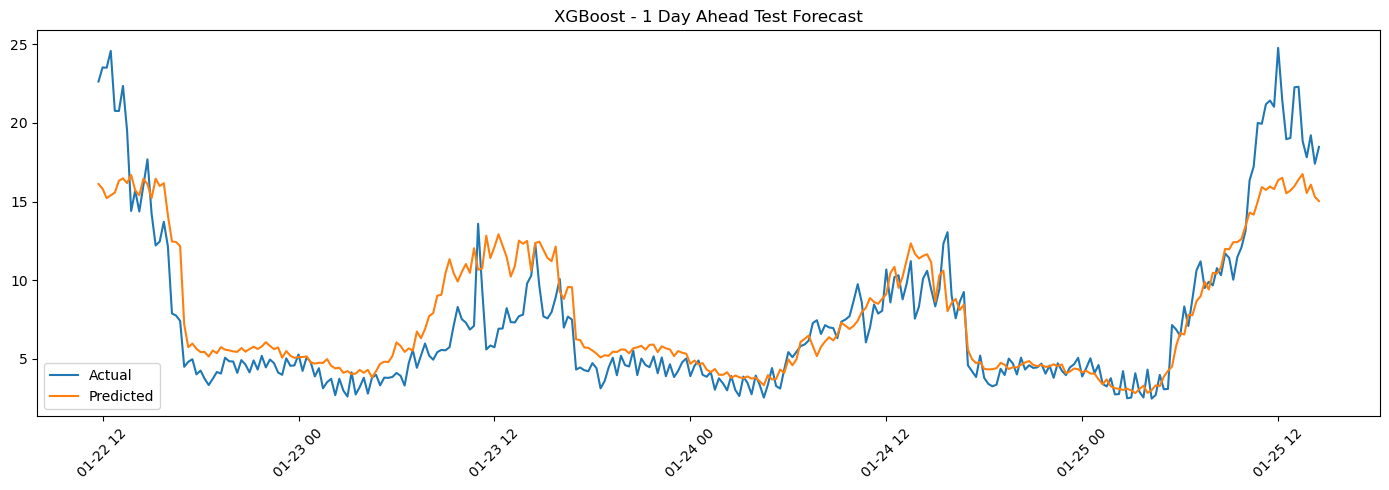

In [8]:
pred = results_xgb_1d["test_predictions"]

plt.figure(figsize=(14, 5))
plt.plot(pred.index[:300], pred["y_true"].iloc[:300], label="Actual")
plt.plot(pred.index[:300], pred["y_pred"].iloc[:300], label="Predicted")
plt.title("XGBoost - 1 Day Ahead Test Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# 1. DEFINE TARGET
# =========================================================
target_col = "BU_TotActPwr_Academy"   # change to your target column

# all columns except target
feature_cols = [c for c in df.columns if c != target_col]

print("Target:", target_col)
print("No. of features:", len(feature_cols))

# =========================================================
# 2. HORIZONS (5-min data)
# =========================================================
HORIZONS = {
    "1h": 4,
    "1d": 672
}

# =========================================================
# 3. METRICS
# =========================================================
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2
    }

# =========================================================
# 4. MAIN FUNCTION
# =========================================================
def train_xgb_with_timeseries_split(
    df,
    target_col,
    feature_cols,
    horizon_steps,
    test_ratio=0.15,
    n_splits=9,
    random_state=42
):
    data = df.copy()

    # create future target
    data["target_future"] = data[target_col].shift(-horizon_steps)

    # drop rows with missing future target
    data = data.dropna(subset=["target_future"])

    # XGBoost can handle missing values internally,
    # but if you want a stricter clean set, uncomment next line:
    # data = data.dropna(subset=feature_cols)

    X = data[feature_cols]
    y = data["target_future"]

    # -----------------------------
    # final chronological split
    # -----------------------------
    n_total = len(data)
    n_test = int(n_total * test_ratio)
    n_train = n_total - n_test

    X_train = X.iloc[:n_train]
    X_test  = X.iloc[n_train:]

    y_train = y.iloc[:n_train]
    y_test  = y.iloc[n_train:]

    print("\n" + "="*70)
    print(f"Horizon steps: {horizon_steps}")
    print(f"Total samples : {n_total}")
    print(f"Train samples : {len(X_train)}")
    print(f"Test samples  : {len(X_test)}")
    print(f"Train period  : {X_train.index.min()} --> {X_train.index.max()}")
    print(f"Test period   : {X_test.index.min()} --> {X_test.index.max()}")

    # -----------------------------
    # TimeSeriesSplit on train only
    # -----------------------------
    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_results = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        model = XGBRegressor(
            n_estimators=2000,
            learning_rate=0.1,
            max_depth=6,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=random_state,
            n_jobs=-1
        )

        model.fit(X_tr, y_tr)

        y_val_pred = model.predict(X_val)
        metrics = calc_metrics(y_val.values, y_val_pred)

        fold_results.append({
            "fold": fold,
            "train_start": X_tr.index.min(),
            "train_end": X_tr.index.max(),
            "val_start": X_val.index.min(),
            "val_end": X_val.index.max(),
            **metrics
        })

        print(
            f"Fold {fold}: "
            f"MAE={metrics['MAE']:.4f}, "
            f"RMSE={metrics['RMSE']:.4f}, "
            f"MAPE={metrics['MAPE_%']:.2f}%, "
            f"R2={metrics['R2']:.4f}"
        )

    cv_results = pd.DataFrame(fold_results)

    print("\nAverage CV metrics:")
    print(cv_results[["MAE", "RMSE", "MAPE_%", "R2"]].mean())

    # -----------------------------
    # final model on full train
    # -----------------------------
    final_model = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.1,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=random_state,
        n_jobs=-1
    )

    final_model.fit(X_train, y_train)

    y_test_pred = final_model.predict(X_test)
    test_metrics = calc_metrics(y_test.values, y_test_pred)

    print("\nFinal Test Metrics:")
    print(test_metrics)

    predictions = pd.DataFrame({
        "y_true": y_test,
        "y_pred": y_test_pred
    }, index=y_test.index)

    feature_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)

    return {
        "model": final_model,
        "cv_results": cv_results,
        "test_metrics": test_metrics,
        "predictions": predictions,
        "feature_importance": feature_importance
    }


Target: BU_TotActPwr_Academy
No. of features: 38


In [17]:

# =========================================================
# 5. RUN FOR 1-HOUR
# =========================================================
results_xgb_1h = train_xgb_with_timeseries_split(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1h"],
    test_ratio=0.15,
    n_splits=9
)



Horizon steps: 4
Total samples : 10652
Train samples : 9055
Test samples  : 1597
Train period  : 2025-10-21 00:00:00 --> 2026-01-23 07:30:00
Test period   : 2026-01-23 07:45:00 --> 2026-02-08 22:45:00
Fold 1: MAE=1.2998, RMSE=1.6553, MAPE=26.87%, R2=0.7671
Fold 2: MAE=1.3251, RMSE=1.9793, MAPE=24.65%, R2=0.7917
Fold 3: MAE=1.3799, RMSE=2.0413, MAPE=15.35%, R2=0.8522
Fold 4: MAE=1.2004, RMSE=1.8459, MAPE=16.57%, R2=0.8837
Fold 5: MAE=1.3337, RMSE=2.0563, MAPE=14.91%, R2=0.8772
Fold 6: MAE=1.2454, RMSE=1.9166, MAPE=17.89%, R2=0.7941
Fold 7: MAE=1.1538, RMSE=1.7334, MAPE=15.43%, R2=0.8990
Fold 8: MAE=1.2979, RMSE=1.8909, MAPE=17.71%, R2=0.9006
Fold 9: MAE=1.3585, RMSE=2.6063, MAPE=16.73%, R2=0.7803

Average CV metrics:
MAE        1.288270
RMSE       1.969477
MAPE_%    18.455043
R2         0.838419
dtype: float64

Final Test Metrics:
{'MAE': 1.6725352121818222, 'RMSE': np.float64(2.8900364763903132), 'MAPE_%': np.float64(16.22799560464149), 'R2': 0.8466506815345609}


In [ ]:

# =========================================================
# 6. RUN FOR 1-week
# =========================================================
results_xgb_1d = train_xgb_with_timeseries_split(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1week"],
    test_ratio=0.15,
    n_splits=9
)


Horizon steps: 672
Total samples : 9984
Train samples : 8487
Test samples  : 1497
Train period  : 2025-10-21 00:00:00 --> 2026-01-17 09:30:00
Test period   : 2026-01-17 09:45:00 --> 2026-02-01 23:45:00
Fold 1: MAE=1.3038, RMSE=1.7892, MAPE=25.47%, R2=0.7889
Fold 2: MAE=2.1664, RMSE=3.1927, MAPE=24.70%, R2=0.6037
Fold 3: MAE=1.8324, RMSE=2.6056, MAPE=30.20%, R2=0.7356
Fold 4: MAE=2.3998, RMSE=3.7977, MAPE=22.45%, R2=0.6435
Fold 5: MAE=1.6292, RMSE=2.4522, MAPE=20.65%, R2=0.7448
Fold 6: MAE=1.7171, RMSE=2.4480, MAPE=27.18%, R2=0.6261
Fold 7: MAE=1.9242, RMSE=3.1330, MAPE=18.96%, R2=0.7221
Fold 8: MAE=2.3457, RMSE=3.8622, MAPE=29.43%, R2=0.6355
Fold 9: MAE=2.0523, RMSE=3.0652, MAPE=28.16%, R2=0.6296

Average CV metrics:
MAE        1.930087
RMSE       2.927322
MAPE_%    25.244974
R2         0.681081
dtype: float64

Final Test Metrics:
{'MAE': 2.496720904281453, 'RMSE': np.float64(4.245191873948161), 'MAPE_%': np.float64(21.40348718776601), 'R2': 0.675535648443957}


In [19]:

# =========================================================
# 7. VIEW RESULTS
# =========================================================
print("\nXGBoost 1-Hour Test Metrics")
print(results_xgb_1h["test_metrics"])

print("\nXGBoost 1-Day Test Metrics")
print(results_xgb_1d["test_metrics"])

print("\nTop 15 Features - 1 Hour")
print(results_xgb_1h["feature_importance"].head(15))

print("\nTop 15 Features - 1 Day")
print(results_xgb_1d["feature_importance"].head(15))


XGBoost 1-Hour Test Metrics
{'MAE': 1.6725352121818222, 'RMSE': np.float64(2.8900364763903132), 'MAPE_%': np.float64(16.22799560464149), 'R2': 0.8466506815345609}

XGBoost 1-Day Test Metrics
{'MAE': 2.496720904281453, 'RMSE': np.float64(4.245191873948161), 'MAPE_%': np.float64(21.40348718776601), 'R2': 0.675535648443957}

Top 15 Features - 1 Hour
                               feature  importance
18          BU_TotActPwr_Academy_lag_1    0.242755
17                           slot_5min    0.205005
9                        minute_of_day    0.111840
5                           is_weekend    0.098759
6                                 hour    0.084299
19          BU_TotActPwr_Academy_lag_2    0.054097
14                   is_business_hours    0.028697
10                             sin_tod    0.027067
30    BU_TotActPwr_Academy_roll_mean_6    0.019985
4                            dayofweek    0.013494
11                             cos_tod    0.011106
20          BU_TotActPwr_Academy_lag_3

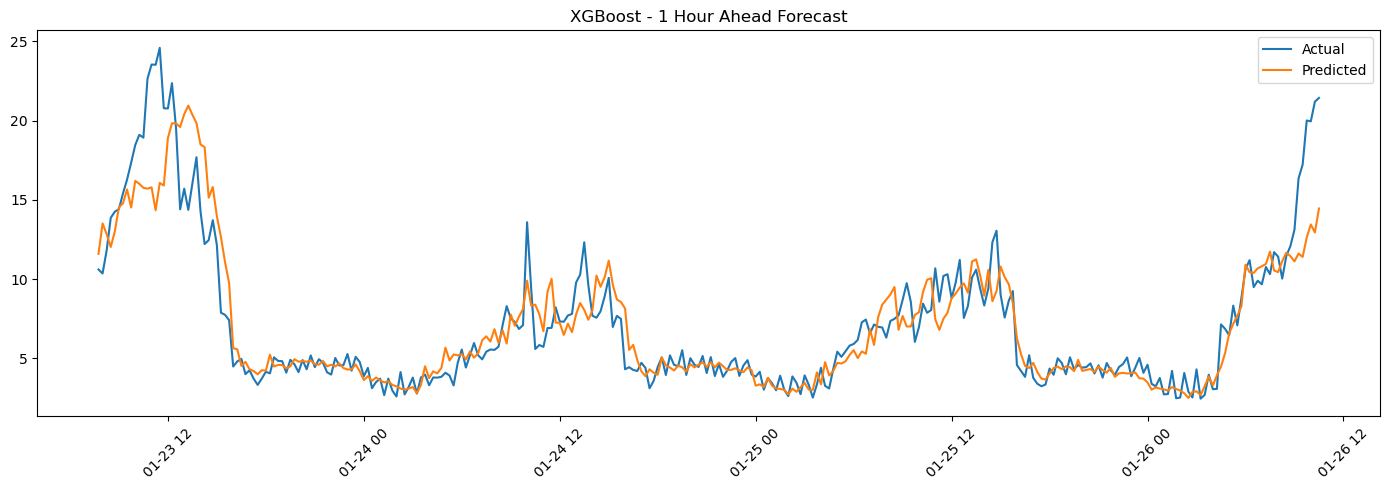

In [20]:
import matplotlib.pyplot as plt

pred_1h = results_xgb_1h["predictions"]

plt.figure(figsize=(14,5))
plt.plot(pred_1h.index[:300], pred_1h["y_true"].iloc[:300], label="Actual")
plt.plot(pred_1h.index[:300], pred_1h["y_pred"].iloc[:300], label="Predicted")
plt.legend()
plt.title("XGBoost - 1 Hour Ahead Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

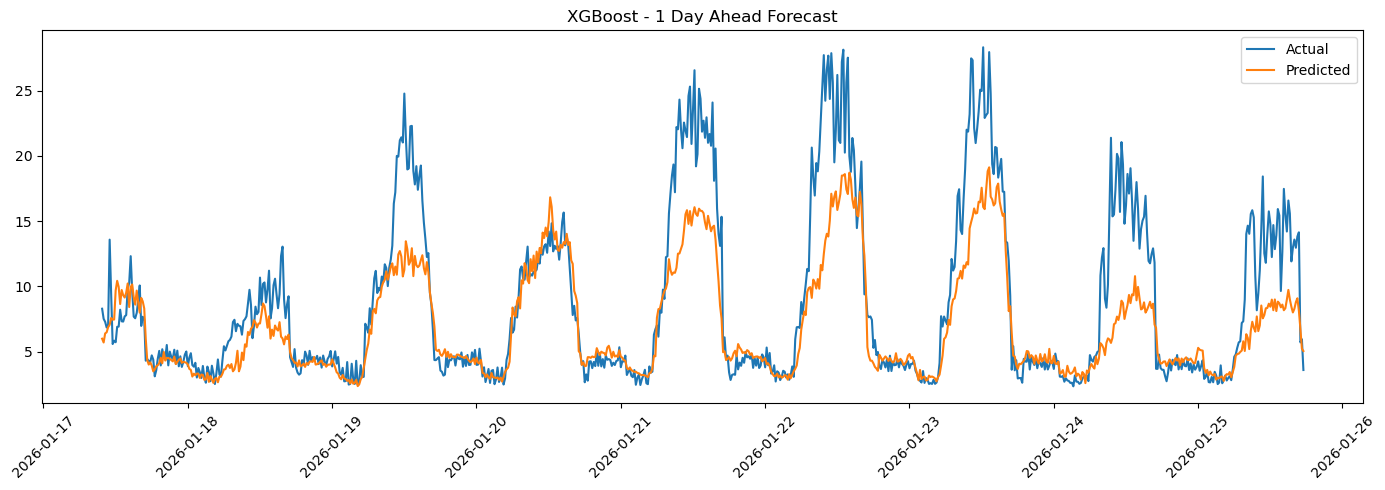

In [22]:
pred_1d = results_xgb_1d["predictions"]

plt.figure(figsize=(14,5))
plt.plot(pred_1d.index[:800], pred_1d["y_true"].iloc[:800], label="Actual")
plt.plot(pred_1d.index[:800], pred_1d["y_pred"].iloc[:800], label="Predicted")
plt.legend()
plt.title("XGBoost - 1 Day Ahead Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()